In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [33]:
import torch
import torchsde
import matplotlib.pyplot as plt
import numpy as np

from control.model import LinearControlSDE

In [3]:
m, k, c = 1.0, 1.0, 0.5
A = torch.tensor([[0.0, 1.0],[-k/m, -c/m]])
B = torch.tensor([[0.0], [1.0/m]])

In [4]:
def compute_gramian(A, B, T, n_steps=200):
    """
    Compute controllability Gramian numerically with trapezoidal integration.
    Wc(T) = ∫_0^T e^{At} B B^T e^{A^T t} dt
    
    Vectorized implementation without explicit loops.
    """
    n = A.shape[0]
    times = torch.linspace(0, T, n_steps + 1, dtype=A.dtype, device=A.device)
    
    # Compute all matrix exponentials at once using vmap
    # Shape: (n_steps+1, n, n)
    At = A.unsqueeze(0) * times.view(-1, 1, 1)
    Et = torch.vmap(torch.matrix_exp)(At)
    
    # Compute Mt = Et @ B @ B^T @ Et^T for all time steps
    # Shape: (n_steps+1, n, n)
    BBT = B @ B.T
    Mt = Et @ BBT @ Et.transpose(-2, -1)
    
    # Apply trapezoidal weights: 0.5 for first and last, 1.0 for middle
    weights = torch.ones(n_steps + 1, dtype=A.dtype, device=A.device)
    weights[0] = 0.5
    weights[-1] = 0.5
    
    # Weighted sum with broadcasting
    Wc = torch.sum(Mt * weights.view(-1, 1, 1), dim=0)
    Wc *= (T / n_steps)
    
    return Wc

In [86]:
def make_u_optimal(A, B, x_target, T, n_steps=2000, regularize=1e-9):
    """
    Build the optimal control function u_optimal(x, t).
    """
    # reshape inputs
    x_target = x_target.reshape(1, -1)

    # Gramian
    Wc = compute_gramian(A, B, T, n_steps=n_steps)
    Wc_reg = Wc + regularize * torch.eye(A.shape[0])
    Wc_inv = torch.inverse(Wc_reg)

    m_exp = torch.matrix_exp(A * T)

    def u_optimal(t, y):
        # ensure column vector
        s = T - t
        term = torch.matrix_exp(A.T * s)
        u = ((x_target - y @ m_exp.T) @ Wc_inv.T) @ term.T @ B
        return u  # return 1D tensor

    return u_optimal

In [105]:
torch.manual_seed(1234)

# Initial condition: [position, velocity]
num_trajectories = 1
y0 = torch.tensor([0.0, 0.0]).repeat(num_trajectories, 1) + 4*torch.randn((num_trajectories,1))
y_target = torch.tensor([1., 1.])

# Time span
t_span = [0.0, 20.0]

# Initialize spring-mass-damper system
control_input = make_u_optimal(A, B, y_target, T=t_span[1])
sde = LinearControlSDE(A, B, control_input=control_input, sigma=0.0)

# Simulate multiple trajectories
ts = torch.linspace(t_span[0], t_span[1], 100)
ys = torchsde.sdeint(sde, y0, ts, method="euler", dt_min=1e-1)

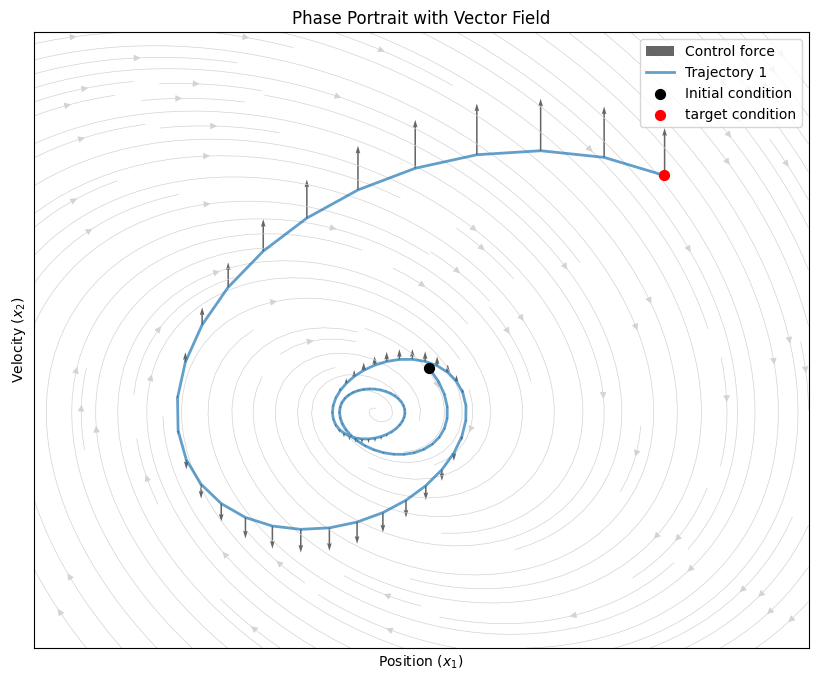

In [ ]:
ts_np = ts.detach().numpy()
ys_np = ys.detach().numpy()

# Phase portrait
plt.figure(figsize=(10, 8))

# Create a grid for the vector field
x1_range = np.linspace(ys_np[:, :, 0].min()-0.5, ys_np[:, :, 0].max()+0.5, 100)
x2_range = np.linspace(ys_np[:, :, 1].min()-0.5, ys_np[:, :, 1].max()+0.5, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute the vector field
Anp = A.detach().cpu().numpy()
U = Anp[0, 0] * X1 + Anp[0, 1] * X2
V = Anp[1, 0] * X1 + Anp[1, 1] * X2

# Plot streamlines
plt.streamplot(X1, X2, U, V, color='lightgray', density=1.5, linewidth=0.5, arrowsize=1)

# Plot trajectories
for i in range(num_trajectories):
    x1_traj = ys_np[:, i, 0]
    x2_traj = ys_np[:, i, 1]
    
    vectorized_control = torch.vmap(control_input, in_dims=(0,0))
    r = vectorized_control(ts, ys[:, i]).squeeze(-1)
    U_traj, V_traj = (torch.matmul(r, B.T).T).detach().numpy()

    # Plot ALL vectors along trajectory
    plt.quiver(x1_traj, x2_traj, U_traj, V_traj,
               scale=5, scale_units='xy', angles='xy',
               width=0.002, alpha=0.6, headwidth=3, label="Control force")

    plt.plot(ys_np[:, i, 0], ys_np[:, i, 1], alpha=0.7, linewidth=2, label=f'Trajectory {i+1}')

plt.scatter(y0[:,0].numpy(), y0[:,1].numpy(), s=50, c="k", zorder=5, label='Initial condition')
plt.scatter(y_target[0].numpy(), y_target[1].numpy(), s=50, c="red", zorder=5, label='target condition')
plt.xlabel('Position ($x_1$)')
plt.ylabel('Velocity ($x_2$)')
plt.title('Phase Portrait with Vector Field')
#plt.grid(True, alpha=0.3)
plt.xticks([]); plt.yticks([])
plt.legend(loc='upper right')
plt.savefig('phase_portrait_sde.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# # Plot results
# fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# # Position
# axes[0].set_title(f'Spring-Mass-Damper System (m={m}, k={k}, c={c})')
# for i in range(num_trajectories):
#     axes[0].plot(ts_np, ys_np[:, i, 0], alpha=0.7, label=f'Trajectory {i+1}')
# axes[0].set_ylabel('Position (x₁)')
# axes[0].grid(True)
# axes[0].legend()

# # Velocity
# for i in range(num_trajectories):
#     axes[1].plot(ts_np, ys_np[:, i, 1], alpha=0.7, label=f'Trajectory {i+1}')
# axes[1].set_xlabel('Time (t)')
# axes[1].set_ylabel('Velocity (x₂)')
# axes[1].grid(True)
# axes[1].legend()

# plt.tight_layout()
# plt.savefig('spring_mass_damper_sde.png', dpi=150, bbox_inches='tight')
# plt.show()
